# Week-7

Decision trees and KNN

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 15

## Decision Trees

**Decision stumps**

A decision stump is a decision tree that has a single question at the root node which splits into two leaf nodes. A decision stump partitions the dataset based on a single question: $f_k < \theta$. This is therefore the simplest decision tree that we can come up with.

---
Use the following decision stump for problems 1 and 3: The root has $1000$ data-points out of which $200$ belong to class-1. The left child-node has $100$ data-points out of which $50$ belong to class-1.

### Problem-1

Write a function `entropy` that accepts the proportion of points that belong to class-1 in a node as argument and returns the entropy. Use $\log_2$ for all computations.

Use this function to compute the entropy of the parent node.

In [2]:
def entropy(p):
    if p == 0 or p == 1:
        return 0
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

# Parent node: 200 out of 1000 → p = 0.2
p_parent = 200/1000
print(entropy(p_parent))


0.7219280948873623


### Problem-2

Plot the entropy of a node as a function of $p$, the proportion of data-points that belong to class $+1$.

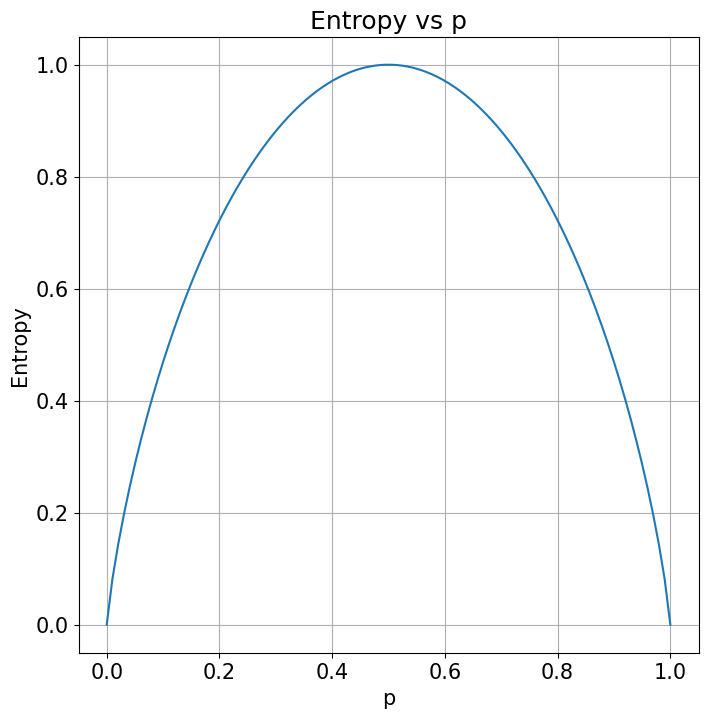

In [3]:
p_vals = np.linspace(0, 1, 100)
H_vals = [entropy(p) for p in p_vals]

plt.plot(p_vals, H_vals)
plt.xlabel("p")
plt.ylabel("Entropy")
plt.title("Entropy vs p")
plt.grid()
plt.show()


### Problem-3

Write a function `IG` that accepts the following arguments:

- `E`: entropy of the parent node `Q`
- `El`: entropy of the left child `L`
- `Er`: entropy of the right child `R`
- `gamma`: proportion of data-points in left child

Use this function to compute the information gain for the parent node.

In [4]:
def IG(E, El, Er, gamma):
    return E - (gamma*El + (1-gamma)*Er)

# Given:
E = entropy(0.2)

# Left node: 50/100 → p = 0.5
El = entropy(0.5)

# Right node: remaining = 900 points, 150 class-1 → p = 150/900
Er = entropy(150/900)

gamma = 100/1000

print(IG(E, El, Er, gamma))



0.03690791540384364


### Problem-4

Consider a decision stump with $1000$ data-points. Call the root node $Q$ and the left and right leaf nodes $L$ and $R$.

- The proportion of data-points that belong to class $+1$ in $Q$ is equal to $0.4$
- The proportion of points in the left node is equal to $0.7$, that is, $\gamma = 0.7$
-  $q$ is the proportion of data-points that belong to class $+1$ in $L$

What are the minimum ($q_{\min}$) and maximum ($q_{\max}$) values of $q$?

In [16]:
# Given
total_points = 1000
total_positive = 0.4 * total_points  # 400

gamma = 0.7
left_points = gamma * total_points  # 700

# q = proportion in left node → left positive = 700q
# constraint: right positive >= 0

q_min = 0
q_max = total_positive / left_points  # 400 / 700

print("qmin =", q_min)
print("qmax =", q_max)


qmin = 0
qmax = 0.5714285714285714


### Problem-5

Using the above information, plot the information gain of the root as a function of $q$, where $q \in [q_{\min}, q_{\max}]$. Record at least two interesting observations.

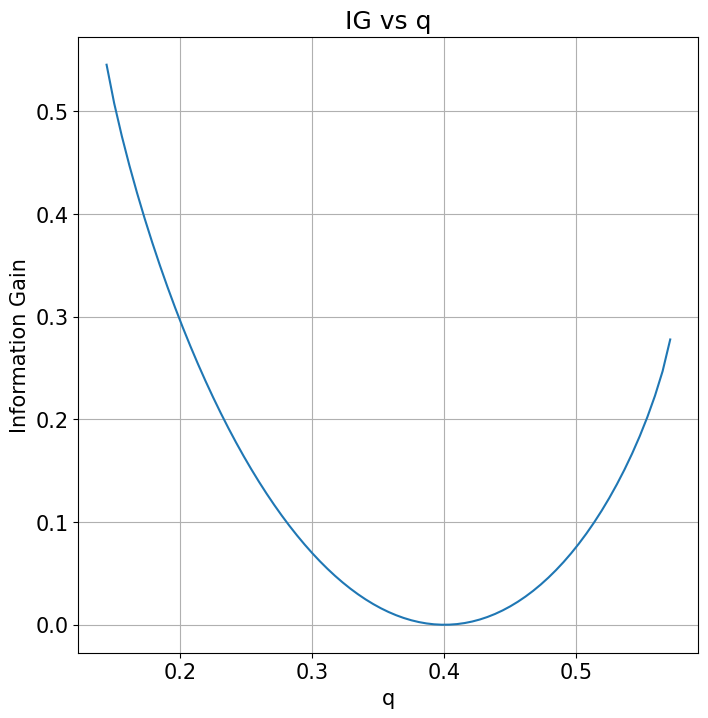

In [5]:
q_vals = np.linspace(0, 0.571, 100)

E = entropy(0.4)
gamma = 0.7

ig_vals = []

for q in q_vals:
    El = entropy(q)

    right_p = (0.4 - gamma*q) / (1 - gamma)
    Er = entropy(right_p)

    ig_vals.append(IG(E, El, Er, gamma))

plt.plot(q_vals, ig_vals)
plt.xlabel("q")
plt.ylabel("Information Gain")
plt.title("IG vs q")
plt.grid()
plt.show()


### Problem-6

We will work with the dataset `X` for the next five problems. Visualize the data using a scatter plot. Color the points that belong to class $+1$ using "green" and those that belong to class $0$ using "red".

In [6]:
### Data ###
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###
rng = np.random.default_rng(seed = 1001)
n_per = 50
cov = np.eye(2) / 10
X1 = rng.multivariate_normal([1, 1], cov, n_per)
y1 = np.ones(n_per)
X2 = rng.multivariate_normal([5, 3], cov , n_per)
y2 = np.zeros(n_per)
X3 = rng.multivariate_normal([3, 4], cov, n_per)
y3 = np.ones(n_per)
X4 = rng.multivariate_normal([3, 2], cov, n_per)
y4 = np.zeros(n_per)
X = np.concatenate((X1, X2, X3, X4), axis = 0)
y = np.int64(np.concatenate((y1, y2, y3, y4)))
### DO NOT CHANGE THE CONTENTS OF THIS CELL ###

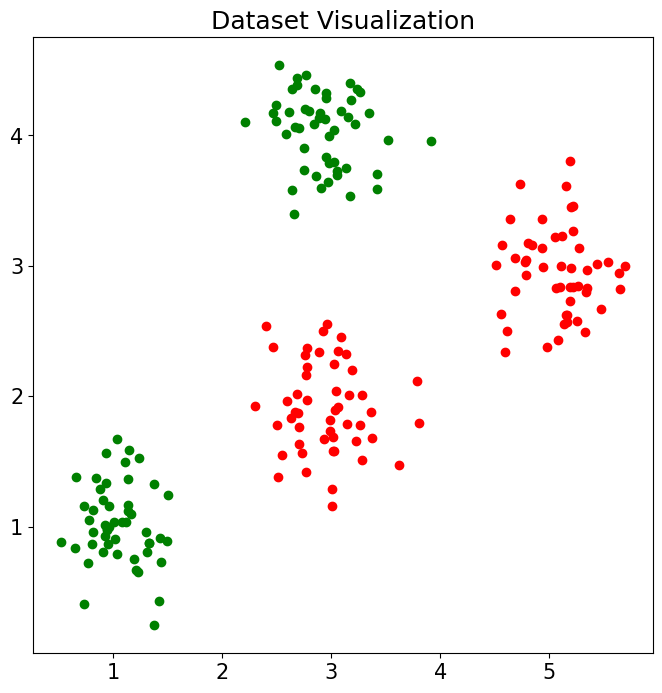

In [7]:
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='green')
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red')
plt.title("Dataset Visualization")
plt.show()


### Problem-7

If you were to use a decision stump as a classifier:

- What is the best question $f_k < \theta$?
    - enter the feature index, $k$ (use zero-indexing)
    - enter the value of $\theta$
- What is the information gain for this question?

---

Write the function named `best_split` to solve this problem:

The function should accept the feature matrix `X` and the label vector `y` as arguements. It should return the tuple `(feat_best, value_best, ig_best)`.

In [8]:
def best_split(X, y):
    best_ig = -1
    feat_best = None
    value_best = None

    for k in range(X.shape[1]):
        values = np.unique(X[:,k])

        for val in values:
            left = y[X[:,k] < val]
            right = y[X[:,k] >= val]

            if len(left) == 0 or len(right) == 0:
                continue

            p = np.mean(y)
            E = entropy(p)

            El = entropy(np.mean(left))
            Er = entropy(np.mean(right))

            gamma = len(left)/len(y)

            ig = IG(E, El, Er, gamma)

            if ig > best_ig:
                best_ig = ig
                feat_best = k
                value_best = val

    return feat_best, value_best, best_ig

print(best_split(X, y))


(0, np.float64(2.2996223648670857), np.float64(0.31925145895127793))


### Problem-8

Grow a decision tree for this problem. You may have to use two programming concepts:

- recursion
- binary trees

Once you have grown the tree, answer the following questions:

- How many internal nodes does your tree have?
- How many leaf nodes does it have?

In [34]:
class Node:
    def __init__(self, feature=None, value=None, left=None, right=None, label=None):
        self.feature = feature
        self.value = value
        self.left = left
        self.right = right
        self.label = label

def build_tree(X, y):
    if len(np.unique(y)) == 1:
        return Node(label=y[0])

    feat, val, ig = best_split(X, y)

    if ig == 0:
        return Node(label=np.bincount(y).argmax())

    left_idx = X[:,feat] < val
    right_idx = X[:,feat] >= val

    left = build_tree(X[left_idx], y[left_idx])
    right = build_tree(X[right_idx], y[right_idx])

    return Node(feat, val, left, right)



### Problem-9

Predict the label of the point $(3, 4)$.

In [35]:
def predict_tree(node, x):
    if node.label is not None:
        return node.label

    if x[node.feature] < node.value:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

tree = build_tree(X, y)
print(predict_tree(tree, np.array([3,4])))


0


### Problem-10

Plot the decision boundary.

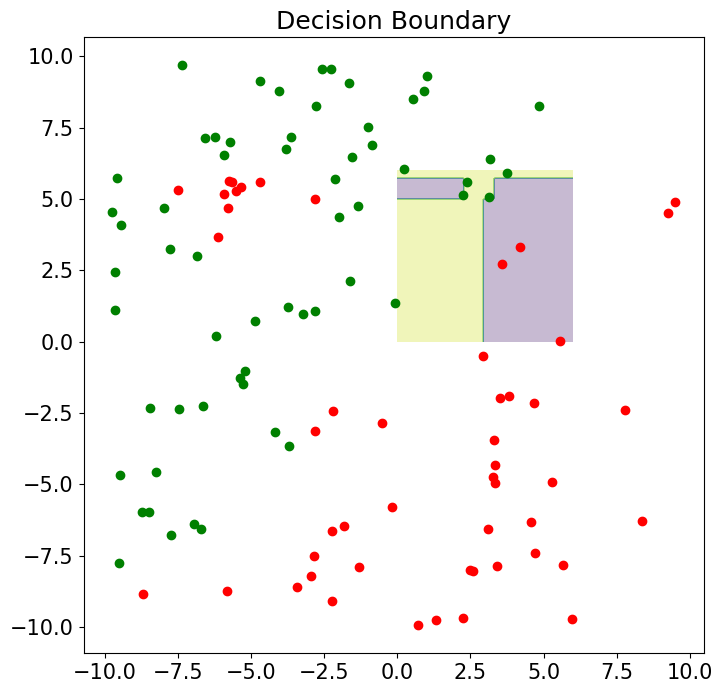

In [29]:
xx, yy = np.meshgrid(np.linspace(0,6,100), np.linspace(0,6,100))

Z = np.array([predict_tree(tree, np.array([x,y]))
              for x,y in zip(xx.ravel(), yy.ravel())])

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='green')
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red')
plt.title("Decision Boundary")
plt.show()


## KNN


In [30]:
### Data ###
### DO NOT EDIT THIS CELL ###
rng = np.random.default_rng(seed = 1001)
X = rng.uniform(-10, 10, (100, 2))
y = np.int32(np.zeros(X.shape[0]))
y[X[:, 1] > X[:, 0]] = 1
X = np.concatenate((X,
                   rng.multivariate_normal([-5, 5], np.eye(2), 10)),
                   axis = 0)
y = np.concatenate((y, np.int32(np.zeros(10))))
### DO NOT EDIT THIS CELL ###

### Problem-11

Visualize the data using a scatter plot. Use red for class $0$ and green for class $1$.

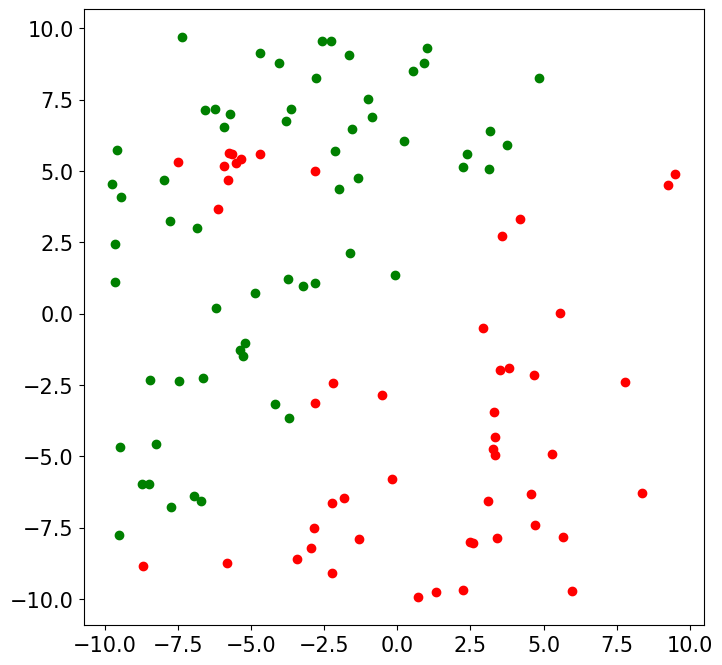

In [31]:
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='green')
plt.show()


### Problem-12

Write a function `predict` that accepts the following arguments:

- `X` - feature matrix
- `y` - label vector
- `x_test` - test data-point
- `k` - number of neighbors

The function should return the prediction for the point `x_test`. Use this function to compute the predicted label for the point $(-3, -2)$ with $k = 10$.

In [32]:
def predict(X, y, x_test, k):
    dists = np.linalg.norm(X - x_test, axis=1)
    idx = np.argsort(dists)[:k]
    return np.bincount(y[idx]).argmax()

print(predict(X, y, np.array([-3,-2]), 10))


1


### Problem-13

Plot the decision boundary for different values of $k$:

- $k = 1$
- $k = 3$
- $k = 7$
- $k = 15$
- $k = 31$
- $k = 63$

Record at least two observations.

In [33]:
def plot_knn(k):
    xx, yy = np.meshgrid(np.linspace(-10,10,100),
                         np.linspace(-10,10,100))

    Z = np.zeros(xx.shape)

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = np.array([xx[i,j], yy[i,j]])
            Z[i,j] = predict(X, y, point, k)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='green')
    plt.title(f"k = {k}")
    plt.show()


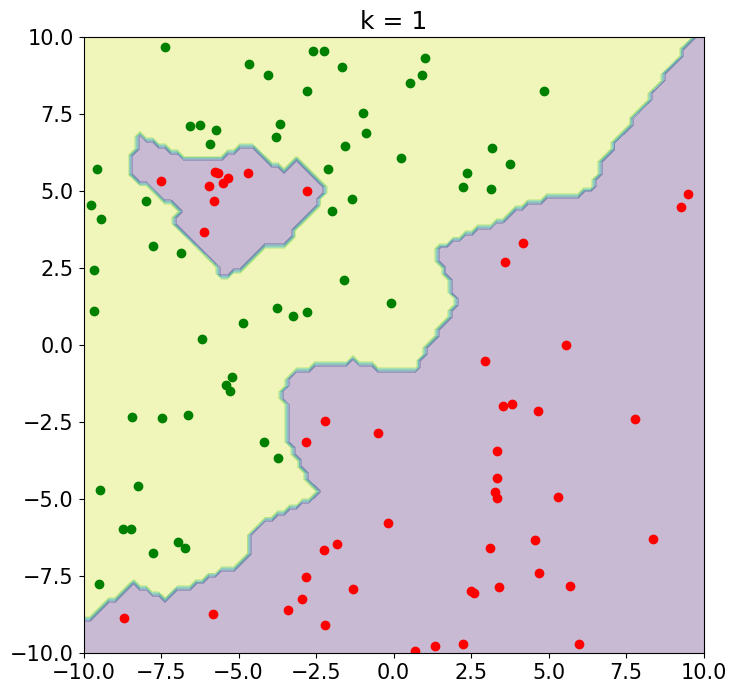

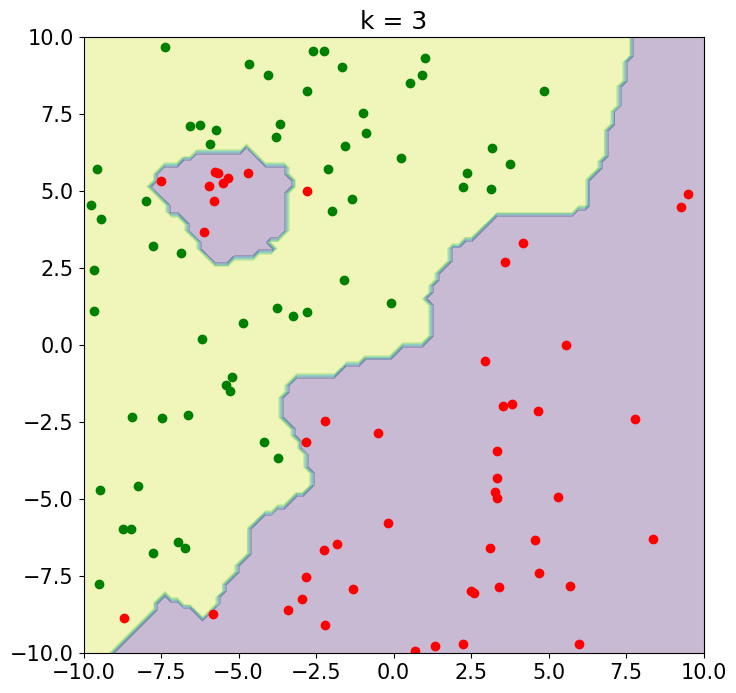

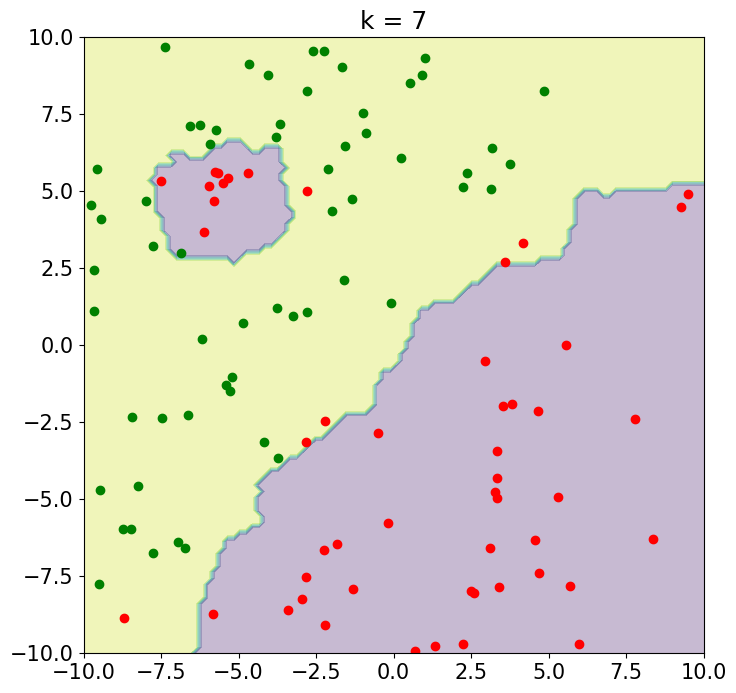

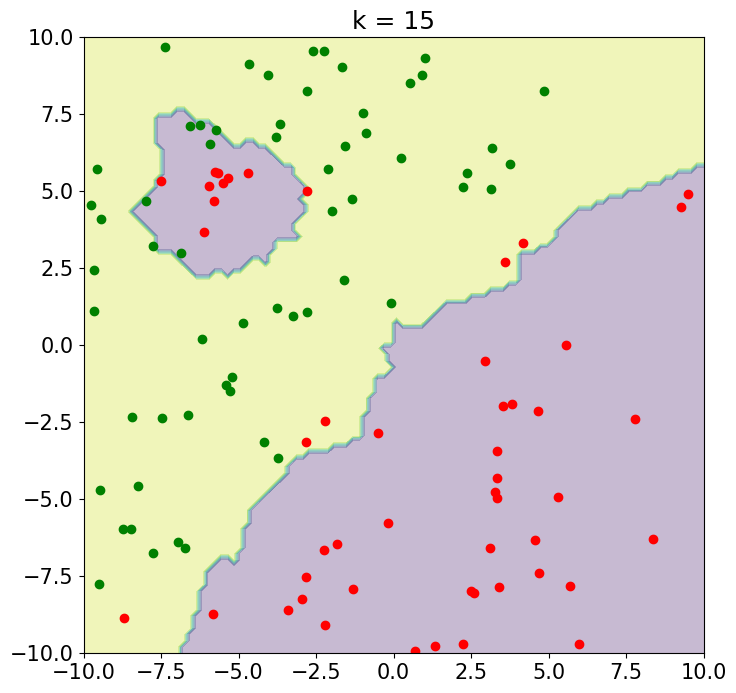

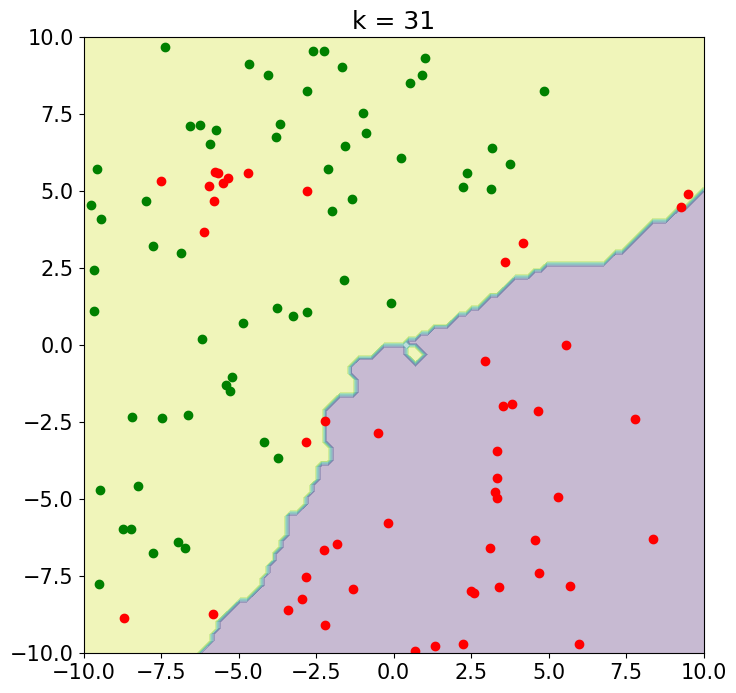

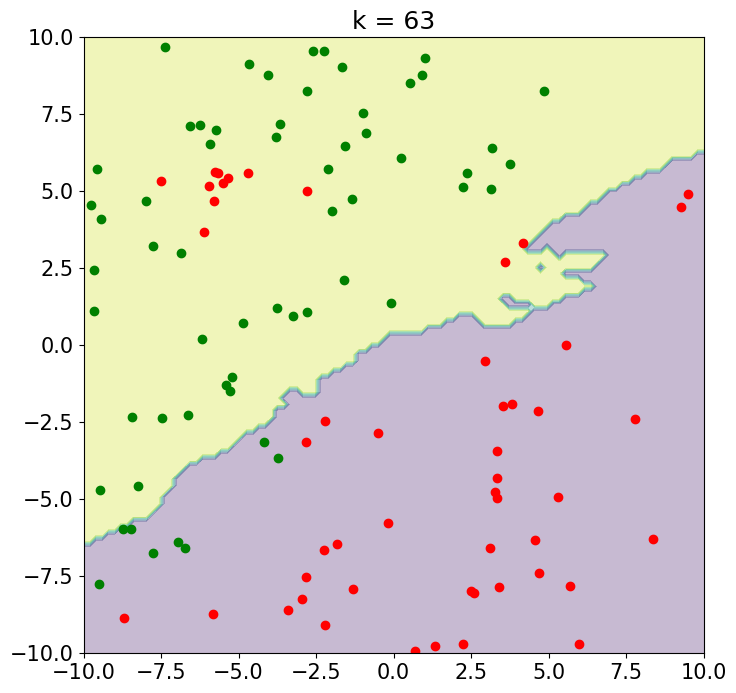

In [36]:
for k in [1,3,7,15,31,63]:
    plot_knn(k)
